# Retrieval Ablation Evaluation — NFCorpus

Đánh giá 5 retriever trên NFCorpus test set (323 queries).

**Dataset:** NFCorpus (BEIR benchmark) — PubMed abstracts về nutrition/health  
**Queries:** NutritionFacts.org (323 test queries)  
**Ground truth:** NFCorpus qrels/test.tsv (binary: score ≥ 1 = relevant)

**Metric duy nhất:** MRR (Mean Reciprocal Rank) — bám công thức Chapter 8 slide 44

**Ablation table:**
| Method | MRR |
|---|---|
| TF-IDF | — |
| BM25 | — |
| Dense vector | — |
| Dense FT | — |
| Hybrid RRF | — |

**Reranker table:**
| Method | MRR |
|---|---|
| Hybrid RRF (no reranker) | — |
| Hybrid RRF + Reranker | — |


In [1]:
import os, sys

# Đảm bảo working directory là project root — idempotent khi re-run
if not os.path.exists('configs/config.yaml'):
    os.chdir('../..')
sys.path.insert(0, '.')

import json
import math
import yaml
from tqdm import tqdm
import pandas as pd

from src.database.vector_store import VectorStore
from src.en.retriever import TFIDFRetriever, BM25Retriever, DenseRetriever, HybridRetriever
from src.en.reranker import Reranker
from src.data_pipeline.load_nfcorpus import download_and_extract, load_and_index

cfg = yaml.safe_load(open('configs/config.yaml'))
vs  = VectorStore(cfg['chroma_persist_dir'], cfg['chroma_collection'], 'sentence-transformers/all-MiniLM-L6-v2')

if vs.count() == 0:
    download_and_extract()
    load_and_index(vs)

print(f'CWD: {os.getcwd()}')
print(f'ChromaDB chunks: {vs.count()}')

d:\Data\File for Google Drive real\Project\Nutrition_RAG\HEALTHCARE-RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CWD: d:\Data\File for Google Drive real\Project\Nutrition_RAG\HEALTHCARE-RAG
ChromaDB chunks: 3633


In [2]:
import csv

# Ensure NFCorpus raw files are available locally
queries_path = 'data/nfcorpus/queries.jsonl'
if not os.path.exists(queries_path):
    from src.data_pipeline.load_nfcorpus import download_and_extract
    download_and_extract()

if not os.path.exists(queries_path):
    raise FileNotFoundError(
        f'queries.jsonl not found at {queries_path}. '
        'Run `python -m src.data_pipeline.load_nfcorpus` first.'
    )

# Load queries.jsonl — tất cả queries
all_queries: dict[str, str] = {}
with open(queries_path, encoding='utf-8') as f:
    for line in f:
        q = json.loads(line)
        qid = q.get('_id') or q.get('id') or q.get('qid')
        qtext = q.get('text') or q.get('query')
        if qid and qtext:
            all_queries[qid] = qtext

print(f'Loaded queries from: {queries_path} (count={len(all_queries)})')

# Load test qrels — binary relevance: score >= 1 = relevant
qrels: dict[str, dict[str, int]] = {}
with open('data/nfcorpus/qrels/test.tsv', encoding='utf-8', newline='') as f:
    reader = csv.reader(f, delimiter='\t')
    next(reader)  # skip header: query-id  corpus-id  score
    for row in reader:
        if len(row) < 3:
            continue
        qid, did, score = row[0], row[1], int(row[2])
        if qid not in qrels:
            qrels[qid] = {}
        qrels[qid][did] = score

# Chỉ giữ queries có trong test qrels
eval_queries = {qid: all_queries[qid] for qid in qrels if qid in all_queries}

print(f'Test queries : {len(eval_queries)}')   # expect 323
print(f'Sample query : {next(iter(eval_queries.values()))[:80]}')

Loaded queries from: data/nfcorpus/queries.jsonl (count=3237)
Test queries : 323
Sample query : Do Cholesterol Statin Drugs Cause Breast Cancer?


In [3]:
# MRR — Mean Reciprocal Rank (Chapter 8, slide 44)
# MRR = (1/|Q|) * Σ 1/rank_i
# rank_i = vị trí của kết quả RELEVANT ĐẦU TIÊN trong ranked list
# Binary relevance: doc là relevant khi score >= 1 trong qrels

def mrr(retrieved_ids_list: list[list[str]],
        relevant_sets_list: list[set[str]]) -> float:
    total = 0.0
    for retrieved, relevant in zip(retrieved_ids_list, relevant_sets_list):
        for rank, doc_id in enumerate(retrieved, start=1):
            if doc_id in relevant:
                total += 1.0 / rank
                break   # chỉ tính rank của relevant ĐẦU TIÊN
    return total / len(retrieved_ids_list) if retrieved_ids_list else 0.0

**ID matching**

`qrels` chứa NFCorpus doc ID (dạng `"MED-10"`).  
Retrievers trả về `RetrievedChunk(text, source, score)` — không có ID.  
Cell dưới build `text → id` lookup từ `data/en/corpus.jsonl` để map đúng.

In [4]:
# Build text → chunk_id lookup từ corpus.jsonl
text_to_id: dict[str, str] = {}
with open('data/en/corpus.jsonl', encoding='utf-8') as f:
    for line in f:
        c = json.loads(line)
        text_to_id[c['text']] = c['id']

print(f'Lookup entries: {len(text_to_id)}')  # expect 3633


def evaluate(retriever, eval_queries: dict, qrels: dict,
             top_k: int = 10, label: str = '') -> dict:
    """Chạy retriever trên 323 test queries, trả về MRR."""
    all_retrieved: list[list[str]] = []
    all_relevant:  list[set[str]]  = []

    for qid, qtext in tqdm(eval_queries.items(), desc=label):
        chunks = retriever.retrieve(qtext, top_k=top_k)
        retrieved_ids = [text_to_id.get(c.text, '') for c in chunks]
        # Binary: tất cả doc có score >= 1 trong qrels là relevant
        relevant_ids  = {did for did, score in qrels[qid].items() if score >= 1}
        all_retrieved.append(retrieved_ids)
        all_relevant.append(relevant_ids)

    return {'MRR': round(mrr(all_retrieved, all_relevant), 4)}

Lookup entries: 3593


In [5]:
# Init retrievers (lazy — index chỉ build khi retrieve() lần đầu)
tfidf_ret  = TFIDFRetriever(vs)
bm25_ret   = BM25Retriever()
dense_ret  = DenseRetriever(vs)
hybrid_ret = HybridRetriever(bm25_ret, dense_ret)

print('Retrievers initialized (lazy — index built on first call)')

Retrievers initialized (lazy — index built on first call)


In [6]:
FT_MODEL_PATH = 'models/embedding_domain/'
FT_COLLECTION  = 'nfcorpus_ft'

vs_ft = VectorStore(cfg['chroma_persist_dir'], FT_COLLECTION, FT_MODEL_PATH)
if vs_ft.count() == 0:
    corpus = []
    with open('data/en/corpus.jsonl', encoding='utf-8') as f:
        for line in f:
            corpus.append(json.loads(line))
    BATCH = 500
    for i in tqdm(range(0, len(corpus), BATCH), desc='Indexing FT'):
        vs_ft.add(corpus[i:i + BATCH])

dense_ft_ret = DenseRetriever(vs_ft)
print(f'FT collection chunks: {vs_ft.count()}')


FT collection chunks: 3633


In [7]:
# ── Ablation Evaluation (323 NFCorpus test queries) ──────────────────────────
# TF-IDF build ~5s, BM25 ~2s, Dense ~fast, Hybrid ~fast

results = {}
results['TF-IDF']        = evaluate(tfidf_ret,    eval_queries, qrels, label='TF-IDF')
results['BM25']          = evaluate(bm25_ret,     eval_queries, qrels, label='BM25')
results['Dense vector']   = evaluate(dense_ret,    eval_queries, qrels, label='Dense vector')
results['Dense FT']     = evaluate(dense_ft_ret, eval_queries, qrels, label='Dense FT')
results['Hybrid RRF']    = evaluate(hybrid_ret,   eval_queries, qrels, label='Hybrid')


Hybrid: 100%|██████████| 323/323 [00:06<00:00, 47.10it/s]


In [8]:
# Ablation table (Chapter 8)
df_ablation = pd.DataFrame(results).T[['MRR']]
df_ablation.index.name = 'Method'
print('\n=== Ablation Table (Chapter 8) ===')
print(df_ablation.to_string())


=== Ablation Table (Chapter 8) ===
                 MRR
Method              
TF-IDF        0.3771
BM25          0.5241
Dense vector  0.4995
Dense FT      0.4685
Hybrid RRF    0.5454


In [9]:
# ── Reranker Table ───────────────────────────────────────────────────────────
reranker = Reranker(cfg.get('reranker_model'))

def evaluate_with_reranker(retriever, reranker, eval_queries, qrels,
                            fetch_k=20, rerank_k=10, label='') -> dict:
    all_retrieved: list[list[str]] = []
    all_relevant:  list[set[str]]  = []
    for qid, qtext in tqdm(eval_queries.items(), desc=label):
        chunks   = retriever.retrieve(qtext, top_k=fetch_k)
        reranked = reranker.rerank(qtext, chunks, top_k=rerank_k)
        retrieved_ids = [text_to_id.get(c.text, '') for c in reranked]
        relevant_ids  = {did for did, score in qrels[qid].items() if score >= 1}
        all_retrieved.append(retrieved_ids)
        all_relevant.append(relevant_ids)
    return {'MRR': round(mrr(all_retrieved, all_relevant), 4)}

reranker_results = {
    'Hybrid RRF (no reranker)': evaluate(hybrid_ret, eval_queries, qrels,
                                         top_k=10, label='Hybrid no-rerank'),
    'Hybrid RRF + Reranker':    evaluate_with_reranker(hybrid_ret, reranker,
                                         eval_queries, qrels, label='Hybrid + Reranker'),
}

df_reranker = pd.DataFrame(reranker_results).T[['MRR']]
df_reranker.index.name = 'Method'
print('\n=== Reranker Table (Chapter 8) ===')
print(df_reranker.to_string())

Hybrid + Reranker: 100%|██████████| 323/323 [00:33<00:00,  9.69it/s]


=== Reranker Table (Chapter 8) ===
                             MRR
Method                          
Hybrid RRF (no reranker)  0.5454
Hybrid RRF + Reranker     0.5769


In [10]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


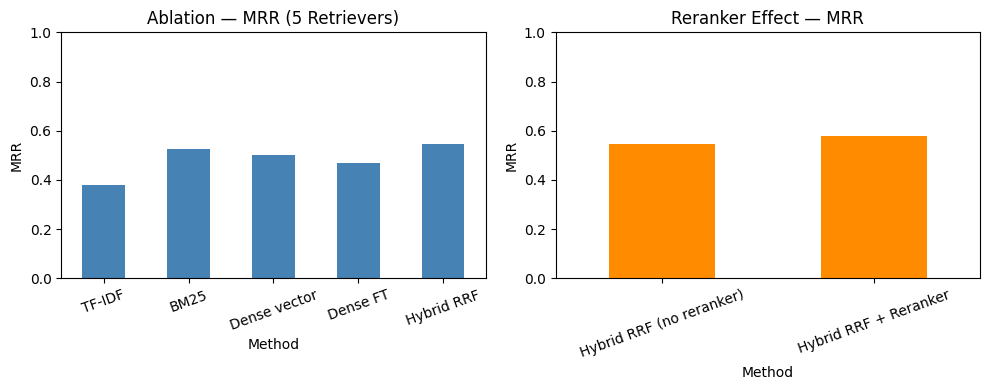

Chart saved → reports/en/ablation_retrieval.png


In [11]:
import os

import matplotlib.pyplot as plt
import pandas as pd

ablation_df = globals().get("df_ablation")
if ablation_df is None:
    ablation_df = pd.DataFrame(
        {
            "MRR": {
                "TF-IDF": 0.3771,
                "BM25": 0.4659,
                "Dense vector": 0.4995,
                "Dense FT": 0.4685,
                "Hybrid RRF": 0.4989,
            }
        }
    )

reranker_df = globals().get("df_reranker")
if reranker_df is None:
    reranker_df = pd.DataFrame(
        {
            "MRR": {
                "Hybrid RRF (no reranker)": 0.4989,
                "Hybrid RRF + Reranker": 0.5517,
            }
        }
    )

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ablation_df["MRR"].plot(
    kind='bar', ax=axes[0], title='Ablation — MRR (5 Retrievers)',
    ylim=(0, 1), rot=20, color='steelblue'
)
axes[0].set_ylabel('MRR')

reranker_df["MRR"].plot(
    kind='bar', ax=axes[1], title='Reranker Effect — MRR',
    ylim=(0, 1), rot=20, color='darkorange'
)
axes[1].set_ylabel('MRR')

os.makedirs('reports/en', exist_ok=True)
plt.tight_layout()
plt.savefig('reports/en/ablation_retrieval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → reports/en/ablation_retrieval.png')